In [1]:
pip install pandas numpy sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
from sqlalchemy import create_engine

# conexión
user = "root"
password = "Johan0922*"
host = "localhost"
port = "3306"
database = "olist_project"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

query = "SELECT COUNT(*) FROM orders"
pd.read_sql(query, engine)

,COUNT(*)
0,96461


In [3]:
pd.read_sql("SHOW TABLES;", engine)

,Tables_in_olist_project
0,customers
1,geolocation
2,order_items
3,order_payments
4,order_reviews
5,orders
6,product_category_name_translation
7,products
8,sellers


In [2]:
query_orders = """
SELECT 
    o.order_id,
    c.customer_unique_id,
    o.order_purchase_timestamp,
    SUM(oi.price + oi.freight_value) AS order_total
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY o.order_id, c.customer_unique_id, o.order_purchase_timestamp
"""

df_orders = pd.read_sql(query_orders, engine)

In [3]:
df_orders.shape

(96455, 4)

In [4]:
df_orders.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_total
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,72.19
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,259.83
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,216.87
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,218.04


In [5]:
orders_per_customer = df_orders.groupby('customer_unique_id')['order_id'].nunique()
single_purchase_rate = (orders_per_customer ==1).mean()*100
single_purchase_rate



                                        

np.float64(97.0000857118368)

In [5]:
df_orders['order_total'].describe()

count    96455.000000
mean       159.828379
std        218.815346
min          9.590000
25%         61.850000
50%        105.280000
75%        176.260000
max      13664.080000
Name: order_total, dtype: float64

### Revenue total

In [6]:
df_orders['order_total'].sum()

np.float64(15416246.25)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

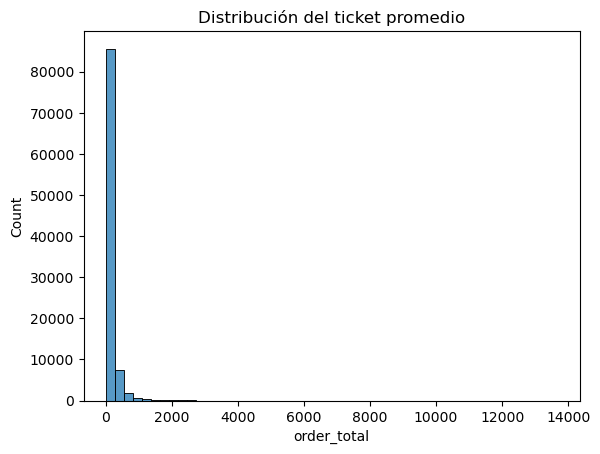

In [8]:
sns.histplot(df_orders['order_total'],bins=50)
plt.title("Distribución del ticket promedio")
plt.show()

In [9]:
df_orders['order_total'].median()

105.28

In [10]:
query_payments = """

SELECT 
    order_id,
    SUM(payment_value) AS total_payment
FROM order_payments
GROUP BY order_id
"""
df_payments =  pd.read_sql(query_payments,engine)

In [11]:
df_payments.describe()

,total_payment
count,96460.000000
mean,159.855721
std,218.828474
min,9.590000
25%,61.880000
50%,105.280000
75%,176.330000
max,13664.080000


In [11]:
df.shape

NameError: name 'df' is not defined

In [12]:
df_payments

,order_id,total_payment
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
96455,fffc94f6ce00a00581880bf54a75a037,343.40
96456,fffcd46ef2263f404302a634eb57f7eb,386.53
96457,fffce4705a9662cd70adb13d4a31832d,116.85
96458,fffe18544ffabc95dfada21779c9644f,64.71


In [13]:
df_customer = df_orders.groupby('customer_unique_id').agg({'order_id':'nunique','order_total':'sum'}).reset_index()

In [14]:
df_customer

,customer_unique_id,order_id,order_total
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89
...,...,...,...
93331,fffcf5a5ff07b0908bd4e2dbc735a684,1,2067.42
93332,fffea47cd6d3cc0a88bd621562a9d061,1,84.58
93333,ffff371b4d645b6ecea244b27531430a,1,112.46
93334,ffff5962728ec6157033ef9805bacc48,1,133.69


In [15]:
df_customer.columns=['customer_id','frequency','monetary']

In [16]:
df_customer.head()

,customer_id,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


In [17]:
df_customer.groupby('frequency')['monetary'].mean()

frequency
1      160.735600
2      291.023344
3      432.784254
4      788.794643
5      734.181111
6      691.112000
7      946.853333
9     1172.670000
15     879.270000
Name: monetary, dtype: float64

In [18]:
df_customer.groupby('frequency')['customer_id'].count().sort_index()

frequency
1     90536
2      2572
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: customer_id, dtype: int64

In [19]:
df_customer['frequency'].value_counts().sort_index() 


frequency
1     90536
2      2572
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [20]:
df_orders

,order_id,customer_unique_id,order_purchase_timestamp,order_total
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,72.19
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,259.83
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,216.87
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,218.04
...,...,...,...,...
96450,fffc94f6ce00a00581880bf54a75a037,0c9aeda10a71f369396d0c04dce13a64,2018-04-23 13:57:06,343.40
96451,fffcd46ef2263f404302a634eb57f7eb,0da9fe112eae0c74d3ba1fe16de0988b,2018-07-14 10:26:46,386.53
96452,fffce4705a9662cd70adb13d4a31832d,cd79b407828f02fdbba457111c38e4c4,2017-10-23 17:07:56,116.85
96453,fffe18544ffabc95dfada21779c9644f,eb803377c9315b564bdedad672039306,2017-08-14 23:02:59,64.71


### Comportamiento de compra


In [21]:
df_orders = df_orders.sort_values(['customer_unique_id','order_purchase_timestamp'])

In [22]:
df_orders

,order_id,customer_unique_id,order_purchase_timestamp,order_total
85405,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90
20125,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19
67417,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22
24473,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62
82003,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89
...,...,...,...,...
43069,725cf8e9c24e679a8a5a32cb92c9ce1e,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2067.42
75064,c71b9252fd7b3b263aaa4cb09319a323,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,84.58
95636,fdc45e6c7555e6cb3cc0daca2557dbe1,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,112.46
55743,94d3ee0bc2a0af9d4fa47a4d63616e8d,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,133.69


In [23]:
## Diferencia entre compras

df_orders['prev_purchase'] = df_orders.groupby('customer_unique_id')['order_purchase_timestamp'].shift(1)

In [24]:
df_orders

,order_id,customer_unique_id,order_purchase_timestamp,order_total,prev_purchase
85405,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,NaT
20125,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,NaT
67417,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,NaT
24473,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,NaT
82003,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,NaT
...,...,...,...,...,...
43069,725cf8e9c24e679a8a5a32cb92c9ce1e,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2067.42,NaT
75064,c71b9252fd7b3b263aaa4cb09319a323,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,84.58,NaT
95636,fdc45e6c7555e6cb3cc0daca2557dbe1,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,112.46,NaT
55743,94d3ee0bc2a0af9d4fa47a4d63616e8d,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,133.69,NaT


In [26]:
df_orders['days_between'] = (df_orders['order_purchase_timestamp']-df_orders['prev_purchase']).dt.days

In [27]:
df_orders

,order_id,customer_unique_id,order_purchase_timestamp,order_total,prev_purchase,days_between
85405,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,NaT,NaN
20125,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,NaT,NaN
67417,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,NaT,NaN
24473,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,NaT,NaN
82003,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,NaT,NaN
...,...,...,...,...,...,...
43069,725cf8e9c24e679a8a5a32cb92c9ce1e,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2067.42,NaT,NaN
75064,c71b9252fd7b3b263aaa4cb09319a323,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,84.58,NaT,NaN
95636,fdc45e6c7555e6cb3cc0daca2557dbe1,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,112.46,NaT,NaN
55743,94d3ee0bc2a0af9d4fa47a4d63616e8d,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,133.69,NaT,NaN


In [28]:
df_orders[df_orders['days_between'].notna()]['days_between'].describe()

count    3119.000000
mean       78.724912
std       107.168909
min         0.000000
25%         0.000000
50%        29.000000
75%       121.000000
max       608.000000
Name: days_between, dtype: float64

In [29]:
df_orders[df_orders['prev_purchase'].notna()]

,order_id,customer_unique_id,order_purchase_timestamp,order_total,prev_purchase,days_between
3086,08204559bebd39e09ee52dcb56d8faa2,004288347e5e88a27ded2bb23747066c,2018-01-14 07:36:54,103.28,2017-07-27 14:13:03,170.0
77864,cea3e6c11eb60acb9d8d4d51694832f8,00a39521eb40f7012db50455bf083460,2018-06-03 10:12:57,26.78,2018-05-23 20:14:21,10.0
80813,d61b915b69851aec8a8865f36cfd793e,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:23,81.78,2017-03-21 19:25:22,0.0
89359,ed0a6265b5b0a292cd537214f401f1fc,011575986092c30523ecb71ff10cb473,2018-04-18 21:58:08,80.32,2018-02-17 15:54:49,60.0
55320,93b35affb86435b71ca01a6dd1eab2b1,011b4adcd54683b480c4d841250a987f,2018-02-15 11:40:57,149.88,2017-08-22 12:51:29,176.0
...,...,...,...,...,...,...
85535,e28a4c66f1484567d1e42b3fab64d923,ff44401d0d8f5b9c54a47374eb48c1b8,2017-05-19 21:20:54,39.00,2017-05-19 21:20:54,0.0
10643,1c308eca3f339414a92e518e2a2e5ee9,ff8892f7c26aa0446da53d01b18df463,2017-11-26 23:25:43,66.74,2017-05-24 16:09:14,186.0
35836,5f79e2da24a52e76bc22897df03a7901,ff922bdd6bafcdf99cb90d7f39cea5b3,2017-08-23 13:15:29,57.60,2017-02-22 12:26:42,182.0
40602,6be1646fccbb69d34b22da3b1807d51d,ff922bdd6bafcdf99cb90d7f39cea5b3,2017-09-14 14:24:04,42.58,2017-08-23 13:15:29,22.0


In [30]:
## Eliminar compras realizadas el mismo día
## La mitad de los clientes que repiten lo hacen en ~2 meses.
df_orders[df_orders['days_between']>0]['days_between'].describe()

count    2197.000000
mean      111.762858
std       112.308407
min         1.000000
25%        23.000000
50%        71.000000
75%       171.000000
max       608.000000
Name: days_between, dtype: float64

In [31]:
## Ciclo de recompra por categoría

df_repeat = df_orders[df_orders['days_between']>0] ## clientes que repiten compra

In [32]:
df_repeat

,order_id,customer_unique_id,order_purchase_timestamp,order_total,prev_purchase,days_between
3086,08204559bebd39e09ee52dcb56d8faa2,004288347e5e88a27ded2bb23747066c,2018-01-14 07:36:54,103.28,2017-07-27 14:13:03,170.0
77864,cea3e6c11eb60acb9d8d4d51694832f8,00a39521eb40f7012db50455bf083460,2018-06-03 10:12:57,26.78,2018-05-23 20:14:21,10.0
89359,ed0a6265b5b0a292cd537214f401f1fc,011575986092c30523ecb71ff10cb473,2018-04-18 21:58:08,80.32,2018-02-17 15:54:49,60.0
55320,93b35affb86435b71ca01a6dd1eab2b1,011b4adcd54683b480c4d841250a987f,2018-02-15 11:40:57,149.88,2017-08-22 12:51:29,176.0
86331,e49d0607832db7c3b1343764225d8df6,012452d40dafae4df401bced74cdb490,2018-05-14 12:12:45,340.07,2017-06-18 22:46:42,329.0
...,...,...,...,...,...,...
8496,169dbd59d432dd792647dc89ba948d40,fed519569d16e690df6f89cb99d4e682,2018-03-18 21:51:49,110.26,2017-12-20 19:10:19,88.0
84304,df52ca7830380e7d8f7292e99434eea7,ff03923ad1eb9e32304deb7f9b2a45c9,2018-05-26 11:51:22,123.53,2018-04-23 21:49:49,32.0
10643,1c308eca3f339414a92e518e2a2e5ee9,ff8892f7c26aa0446da53d01b18df463,2017-11-26 23:25:43,66.74,2017-05-24 16:09:14,186.0
35836,5f79e2da24a52e76bc22897df03a7901,ff922bdd6bafcdf99cb90d7f39cea5b3,2017-08-23 13:15:29,57.60,2017-02-22 12:26:42,182.0


In [33]:
df_customer.groupby(df_customer['frequency']>1)['monetary'].mean()

frequency
False    160.735600
True     308.531404
Name: monetary, dtype: float64

In [34]:
df_customer.groupby(df_customer['frequency']>1)['monetary'].mean()

frequency
False    160.735600
True     308.531404
Name: monetary, dtype: float64

In [35]:
df_repeat_customers = (df_customer['frequency']>1).sum() ## usamos SUM porque True y False funcionan como 1 y 0
df_repeat_customers

np.int64(2800)

In [36]:
df_no_repeat_customers = (df_customer['frequency']==1).sum()

In [37]:
df_no_repeat_customers

np.int64(90536)

In [38]:
(df_customer['frequency']==1).sum()+ (df_customer['frequency']>1).sum()

np.int64(93336)

In [39]:
df_customer[df_customer['frequency']>1]['monetary'].mean()

np.float64(308.53140357142854)

In [40]:
df_customer[df_customer['frequency']>1]['monetary'].sum()

np.float64(863887.9299999999)

In [41]:
df_customer[df_customer['frequency']>1]['monetary'].sum()/df_repeat_customers

np.float64(308.53140357142854)

In [42]:
df_customer[df_customer['frequency']==1]['monetary'].sum()/df_no_repeat_customers

np.float64(160.73560042414067)

In [43]:

### Incremental que genera un cliente cuando pasa de comprar una vez a compra
incremental = df_customer[df_customer['frequency']>1]['monetary'].sum()/df_repeat_customers-df_customer[df_customer['frequency']==1]['monetary'].sum()/df_no_repeat_customers

In [44]:
incremental

np.float64(147.79580314728787)

In [45]:
df_no_repeat_customers*0.05

np.float64(4526.8)

In [46]:
## Impacto en revenue con 5% en incremento de retención

(df_no_repeat_customers*0.05)*incremental

np.float64(669042.0416871428)

In [47]:
import pandas as pd

In [48]:
snapshot_date = df_orders['order_purchase_timestamp'].max()+pd.Timedelta(days=1)

In [49]:
snapshot_date 

Timestamp('2018-08-30 15:00:37')

In [50]:
df_rfm = df_orders.groupby('customer_unique_id').agg({'order_purchase_timestamp':lambda x:(snapshot_date-x.max()).days,'order_id':'nunique','order_total':'sum'}).reset_index()

In [51]:
df_rfm.columns = ['customer_id','recency','frequency','monetary']

In [53]:
df_rfm.describe()

,recency,frequency,monetary
count,93336.000000,93336.000000,93336.000000
mean,237.903853,1.033417,165.169348
std,152.552964,0.209098,226.313356
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.010000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.495000
max,714.000000,15.000000,13664.080000


### Creación de Score 

In [54]:
df_rfm['R_score'] = pd.qcut(df_rfm['recency'],5,labels = [5,4,3,2,1])
df_rfm['F_score'] = pd.qcut(df_rfm['frequency'].rank(method = 'first'),5,labels =[1,2,3,4,5]) ## First permite asignar ranking segun el orden en que aparecen para cuando hay empates y evitar valores repetidos en cut que no los acepta
df_rfm['M_score'] = pd.qcut(df_rfm['monetary'],5,labels = [1,2,3,4,5])

df_rfm['RFM_score'] = (
    df_rfm['R_score'].astype(str)+
    df_rfm['F_score'].astype(str)+
    df_rfm['M_score'].astype(str)
)

In [55]:
df_rfm.describe()

,recency,frequency,monetary
count,93336.000000,93336.000000,93336.000000
mean,237.903853,1.033417,165.169348
std,152.552964,0.209098,226.313356
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.010000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.495000
max,714.000000,15.000000,13664.080000


In [56]:
df_rfm.groupby('RFM_score').agg({'customer_id':'count','monetary':'mean'}).sort_values('monetary',ascending = False).head(10)

,customer_id,monetary
RFM_score,,
535,699,476.165680
415,704,469.743139
215,699,461.506867
155,851,458.950458
235,731,458.054446
245,684,457.527792
455,959,454.598071
225,746,453.757534
555,1000,450.305890


In [57]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Potential Loyalist'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

df_rfm['segment'] = df_rfm.apply(segment_customer, axis=1)

In [59]:
df_rfm.groupby('segment')['customer_id'].count()

segment
At Risk               14984
Champions             14959
Others                44567
Potential Loyalist    18826
Name: customer_id, dtype: int64

In [62]:
df_rfm

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Others
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,At Risk
...,...,...,...,...,...,...,...,...,...
93331,fffcf5a5ff07b0908bd4e2dbc735a684,447,1,2067.42,1,5,5,155,Others
93332,fffea47cd6d3cc0a88bd621562a9d061,262,1,84.58,3,5,2,352,Potential Loyalist
93333,ffff371b4d645b6ecea244b27531430a,568,1,112.46,1,5,3,153,Others
93334,ffff5962728ec6157033ef9805bacc48,119,1,133.69,4,5,4,454,Champions


In [61]:
df_rfm.groupby('segment').agg({
    'customer_id':'count',
    'monetary':['mean','sum']
}).sort_values(('monetary','sum'), ascending=False)

customer_id    monetary            
                         count        mean         sum
segment                                               
Others                   44567  163.604014  7291340.09
Potential Loyalist       18826  161.289667  3036439.28
Champions                14959  176.945072  2646921.33
At Risk                  14984  162.943510  2441545.55

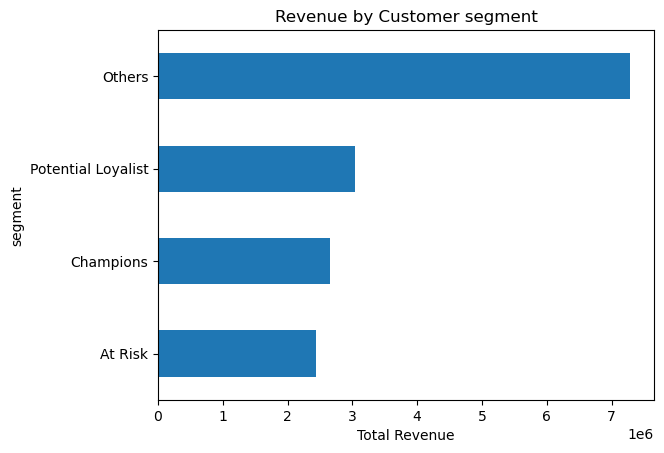

In [63]:
import matplotlib.pyplot as plt

segment_revenue = df_rfm.groupby('segment')['monetary'].sum().sort_values()

segment_revenue.plot(kind='barh')

plt.title('Revenue by Customer segment')
plt.xlabel('Total Revenue')
plt.ylabel('segment')

plt.show()

In [64]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

In [65]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 85405 to 93275
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96455 non-null  object        
 1   customer_unique_id        96455 non-null  object        
 2   order_purchase_timestamp  96455 non-null  datetime64[ns]
 3   order_total               96455 non-null  float64       
 4   prev_purchase             3119 non-null   datetime64[ns]
 5   days_between              3119 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(2)
memory usage: 5.2+ MB


In [66]:
df_orders['order_month']=df_orders['order_purchase_timestamp'].dt.to_period('M')

In [67]:
df_orders

,order_id,customer_unique_id,order_purchase_timestamp,order_total,prev_purchase,days_between,order_month
85405,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,NaT,NaN,2018-05
20125,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,NaT,NaN,2018-05
67417,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,NaT,NaN,2017-03
24473,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,NaT,NaN,2017-10
82003,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,NaT,NaN,2017-11
...,...,...,...,...,...,...,...
43069,725cf8e9c24e679a8a5a32cb92c9ce1e,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2067.42,NaT,NaN,2017-06
75064,c71b9252fd7b3b263aaa4cb09319a323,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,84.58,NaT,NaN,2017-12
95636,fdc45e6c7555e6cb3cc0daca2557dbe1,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,112.46,NaT,NaN,2017-02
55743,94d3ee0bc2a0af9d4fa47a4d63616e8d,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,133.69,NaT,NaN,2018-05


In [68]:
df_orders['cohort']  =df_orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')

In [69]:
df_orders

,order_id,customer_unique_id,order_purchase_timestamp,order_total,prev_purchase,days_between,order_month,cohort
85405,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,NaT,NaN,2018-05,2018-05
20125,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,NaT,NaN,2018-05,2018-05
67417,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,NaT,NaN,2017-03,2017-03
24473,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,NaT,NaN,2017-10,2017-10
82003,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,NaT,NaN,2017-11,2017-11
...,...,...,...,...,...,...,...,...
43069,725cf8e9c24e679a8a5a32cb92c9ce1e,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2067.42,NaT,NaN,2017-06,2017-06
75064,c71b9252fd7b3b263aaa4cb09319a323,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,84.58,NaT,NaN,2017-12,2017-12
95636,fdc45e6c7555e6cb3cc0daca2557dbe1,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,112.46,NaT,NaN,2017-02,2017-02
55743,94d3ee0bc2a0af9d4fa47a4d63616e8d,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,133.69,NaT,NaN,2018-05,2018-05


In [72]:
df_orders['cohort_index']=(
    (df_orders['order_month'].dt.year - df_orders['cohort'].dt.year)*12+
    (df_orders['order_month'].dt.month -df_orders['cohort'].dt.month)+1
)

In [73]:
df_orders

,order_id,customer_unique_id,order_purchase_timestamp,order_total,prev_purchase,days_between,order_month,cohort,cohort_index
85405,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,NaT,NaN,2018-05,2018-05,1
20125,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,NaT,NaN,2018-05,2018-05,1
67417,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,NaT,NaN,2017-03,2017-03,1
24473,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,NaT,NaN,2017-10,2017-10,1
82003,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,NaT,NaN,2017-11,2017-11,1
...,...,...,...,...,...,...,...,...,...
43069,725cf8e9c24e679a8a5a32cb92c9ce1e,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2067.42,NaT,NaN,2017-06,2017-06,1
75064,c71b9252fd7b3b263aaa4cb09319a323,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,84.58,NaT,NaN,2017-12,2017-12,1
95636,fdc45e6c7555e6cb3cc0daca2557dbe1,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,112.46,NaT,NaN,2017-02,2017-02,1
55743,94d3ee0bc2a0af9d4fa47a4d63616e8d,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,133.69,NaT,NaN,2018-05,2018-05,1


In [74]:
cohort_data = df_orders.groupby(['cohort','cohort_index'])['customer_unique_id'].nunique().reset_index()

In [75]:
cohort_data

,cohort,cohort_index,customer_unique_id
0,2016-09,1,1
1,2016-10,1,262
2,2016-10,7,1
3,2016-10,10,1
4,2016-10,12,1
...,...,...,...
214,2018-06,2,25
215,2018-06,3,16
216,2018-07,1,5946
217,2018-07,2,31


In [76]:
cohort_table=cohort_data.pivot(index='cohort',columns ='cohort_index',values='customer_unique_id')

In [77]:
cohort_table

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,715.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1616.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,1.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
2017-04,2256.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3450.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
2017-06,3037.0,15.0,12.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN


In [78]:
cohort_size = cohort_table.iloc[:,0]

retention = cohort_table.divide(cohort_size, axis=0)

In [79]:
retention

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002797,0.002797,0.001399,0.004196,0.001399,0.004196,0.001399,0.001399,NaN,0.004196,0.001399,0.006993,0.004196,0.001399,0.001399,0.002797,0.004196,0.001399,NaN
2017-02,1.0,0.001856,0.003094,0.001238,0.004332,0.001238,0.002475,0.001856,0.000619,0.001856,0.001238,0.003094,0.001238,0.001856,0.001238,0.000619,0.000619,0.001856,NaN,NaN
2017-03,1.0,0.004395,0.003596,0.003995,0.003596,0.001598,0.001598,0.003196,0.003196,0.000799,0.003596,0.001199,0.001998,0.001199,0.001598,0.002397,0.000799,0.001199,NaN,NaN
2017-04,1.0,0.006206,0.002216,0.001773,0.002660,0.002660,0.003546,0.003103,0.003103,0.001773,0.002660,0.000887,0.000443,0.000443,0.000887,0.000887,0.001330,NaN,NaN,NaN
2017-05,1.0,0.004638,0.004638,0.002899,0.002899,0.003188,0.004058,0.001449,0.002609,0.002609,0.002609,0.003478,0.002319,0.000290,0.001739,0.002029,NaN,NaN,NaN,NaN
2017-06,1.0,0.004939,0.003951,0.004281,0.002963,0.003951,0.003622,0.002305,0.001317,0.001976,0.002963,0.003622,0.001646,0.001646,0.002305,NaN,NaN,NaN,NaN,NaN


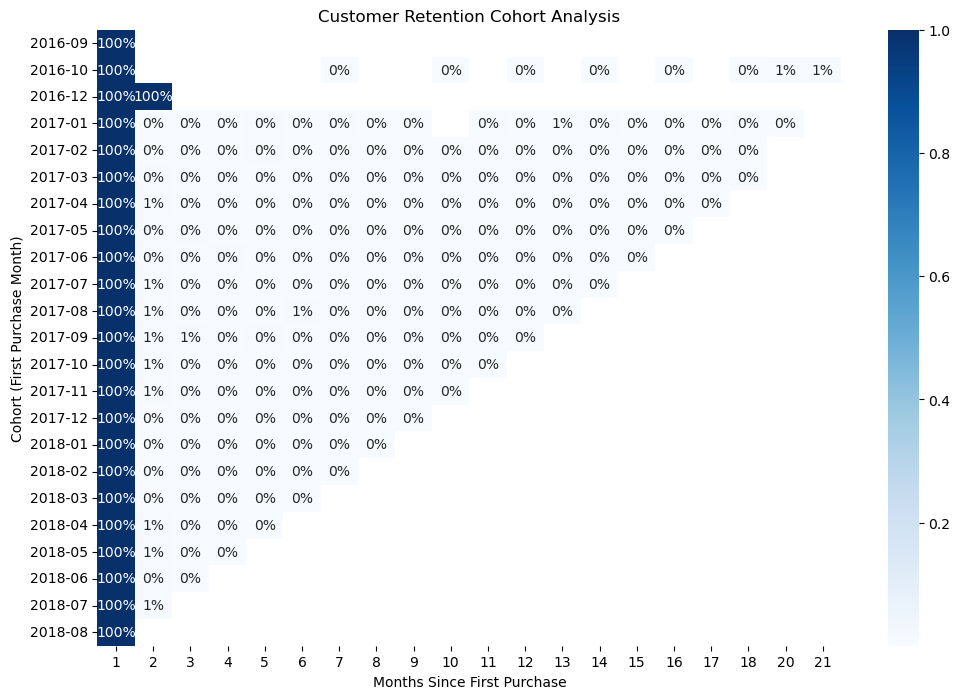

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(retention,
            annot=True,
            fmt='.0%',
            cmap='Blues')

plt.title('Customer Retention Cohort Analysis')
plt.ylabel('Cohort (First Purchase Month)')
plt.xlabel('Months Since First Purchase')

plt.show()

In [80]:
df_orders.info

<bound method DataFrame.info of                                order_id                customer_unique_id  \
85405  e22acc9c116caa3f2b7121bbb380d08e  0000366f3b9a7992bf8c76cfdf3221e2   
20125  3594e05a005ac4d06a72673270ef9ec9  0000b849f77a49e4a4ce2b2a4ca5be3f   
67417  b33ec3b699337181488304f362a6b734  0000f46a3911fa3c0805444483337064   
24473  41272756ecddd9a9ed0180413cc22fb6  0000f6ccb0745a6a4b88665a16c9f078   
82003  d957021f1127559cd947b62533f484f7  0004aac84e0df4da2b147fca70cf8255   
...                                 ...                               ...   
43069  725cf8e9c24e679a8a5a32cb92c9ce1e  fffcf5a5ff07b0908bd4e2dbc735a684   
75064  c71b9252fd7b3b263aaa4cb09319a323  fffea47cd6d3cc0a88bd621562a9d061   
95636  fdc45e6c7555e6cb3cc0daca2557dbe1  ffff371b4d645b6ecea244b27531430a   
55743  94d3ee0bc2a0af9d4fa47a4d63616e8d  ffff5962728ec6157033ef9805bacc48   
93275  f79a35da168301ae56922475da21117b  ffffd2657e2aad2907e67c3e9daecbeb   

      order_purchase_timestamp  order_total

In [81]:
df_customer

,customer_id,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89
...,...,...,...
93331,fffcf5a5ff07b0908bd4e2dbc735a684,1,2067.42
93332,fffea47cd6d3cc0a88bd621562a9d061,1,84.58
93333,ffff371b4d645b6ecea244b27531430a,1,112.46
93334,ffff5962728ec6157033ef9805bacc48,1,133.69


In [82]:
df_customer.to_csv("customer_rfm.csv",index = False)

In [83]:
import os
os.getcwd()

'C:\\Users\\johan\\OneDrive\\Documentos\\Documentos Johan\\CURSOS Y DIPLOMADOS\\Unicorn\\portafolio'

In [84]:
df_customer

,customer_id,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89
...,...,...,...
93331,fffcf5a5ff07b0908bd4e2dbc735a684,1,2067.42
93332,fffea47cd6d3cc0a88bd621562a9d061,1,84.58
93333,ffff371b4d645b6ecea244b27531430a,1,112.46
93334,ffff5962728ec6157033ef9805bacc48,1,133.69


In [88]:
os.listdir()

['.ipynb_checkpoints', 'customer_rfm.csv', 'Untitled.ipynb']

In [85]:
df_customer['monetary'].describe()

count    93336.000000
mean       165.169348
std        226.313356
min          9.590000
25%         63.010000
50%        107.780000
75%        182.495000
max      13664.080000
Name: monetary, dtype: float64

In [86]:
df_rfm

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Others
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,At Risk
...,...,...,...,...,...,...,...,...,...
93331,fffcf5a5ff07b0908bd4e2dbc735a684,447,1,2067.42,1,5,5,155,Others
93332,fffea47cd6d3cc0a88bd621562a9d061,262,1,84.58,3,5,2,352,Potential Loyalist
93333,ffff371b4d645b6ecea244b27531430a,568,1,112.46,1,5,3,153,Others
93334,ffff5962728ec6157033ef9805bacc48,119,1,133.69,4,5,4,454,Champions


In [87]:
df_customer

,customer_id,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89
...,...,...,...
93331,fffcf5a5ff07b0908bd4e2dbc735a684,1,2067.42
93332,fffea47cd6d3cc0a88bd621562a9d061,1,84.58
93333,ffff371b4d645b6ecea244b27531430a,1,112.46
93334,ffff5962728ec6157033ef9805bacc48,1,133.69


In [88]:
df_rfm = df_rfm.rename(columns={'customer_id':'customer_unique_id'})

In [89]:
df_rfm

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Others
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,At Risk
...,...,...,...,...,...,...,...,...,...
93331,fffcf5a5ff07b0908bd4e2dbc735a684,447,1,2067.42,1,5,5,155,Others
93332,fffea47cd6d3cc0a88bd621562a9d061,262,1,84.58,3,5,2,352,Potential Loyalist
93333,ffff371b4d645b6ecea244b27531430a,568,1,112.46,1,5,3,153,Others
93334,ffff5962728ec6157033ef9805bacc48,119,1,133.69,4,5,4,454,Champions


In [117]:
df_rfm.to_excel("customer_rfm.xlsx",index=False)

In [114]:
df_rfm['monetary'].describe()

count    93336.000000
mean       165.169348
std        226.313356
min          9.590000
25%         63.010000
50%        107.780000
75%        182.495000
max      13664.080000
Name: monetary, dtype: float64

In [112]:
df_rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Others
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,At Risk


In [115]:
df_rfm['monetary'].dtype

dtype('float64')

In [116]:
df_rfm['monetary'] = pd.to_numeric(df_rfm['monetary'],errors = 'coerce')

In [113]:
df_rfm['monetary'].dtype

dtype('float64')

In [104]:
df_rfm

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Others
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,At Risk
...,...,...,...,...,...,...,...,...,...
93331,fffcf5a5ff07b0908bd4e2dbc735a684,447,1,2067.42,1,5,5,155,Others
93332,fffea47cd6d3cc0a88bd621562a9d061,262,1,84.58,3,5,2,352,Potential Loyalist
93333,ffff371b4d645b6ecea244b27531430a,568,1,112.46,1,5,3,153,Others
93334,ffff5962728ec6157033ef9805bacc48,119,1,133.69,4,5,4,454,Champions


In [105]:
df_orders.to_excel("orders.xlsx",index=False)

In [118]:
df_orders

,order_id,customer_unique_id,order_purchase_timestamp,order_total,prev_purchase,days_between,order_month,cohort,cohort_index
85405,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,NaT,NaN,2018-05,2018-05,1
20125,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,NaT,NaN,2018-05,2018-05,1
67417,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,NaT,NaN,2017-03,2017-03,1
24473,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,NaT,NaN,2017-10,2017-10,1
82003,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,NaT,NaN,2017-11,2017-11,1
...,...,...,...,...,...,...,...,...,...
43069,725cf8e9c24e679a8a5a32cb92c9ce1e,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2067.42,NaT,NaN,2017-06,2017-06,1
75064,c71b9252fd7b3b263aaa4cb09319a323,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,84.58,NaT,NaN,2017-12,2017-12,1
95636,fdc45e6c7555e6cb3cc0daca2557dbe1,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,112.46,NaT,NaN,2017-02,2017-02,1
55743,94d3ee0bc2a0af9d4fa47a4d63616e8d,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,133.69,NaT,NaN,2018-05,2018-05,1
